In [1]:
import pandas as pd
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# y=df['Spending Score (1-100)']
# x=df.drop(columns=['Spending Score (1-100)'])

# from scipy import stats
# feat=[]
# sk,kt=0,0
# for i in x.select_dtypes(include='number').columns:
#     sk=abs(x[i].skew())
#     kt=abs(x[i].kurt())
#     reg,pval=0,0
#     if sk<=1 and kt<=1:
#         reg,pval=stats.pearsonr(x[i],y)
#     else:
#         reg,pval=stats.spearmanr(x[i],y)
#     if pval<0.05:
#         feat.append(i)

# df['Genre'].nunique()

# gp=[grp['Spending Score (1-100)'].values for name,grp in df.groupby('Genre')]
# fstat,pval=stats.ttest_ind(*gp)
# if pval<0.05:
#     feat.append('Genre')

In [3]:
x=df.iloc[:,3:]
print(x)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


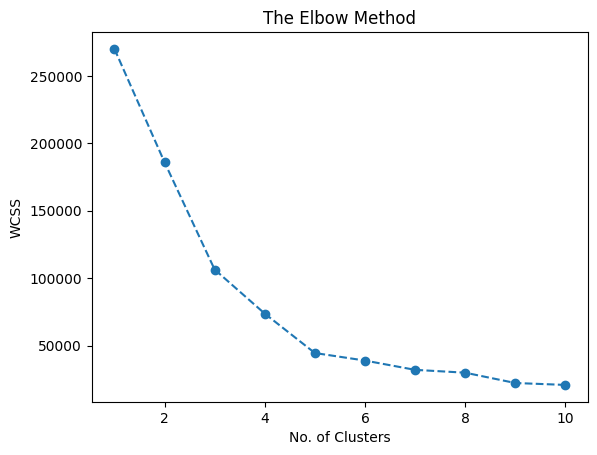

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

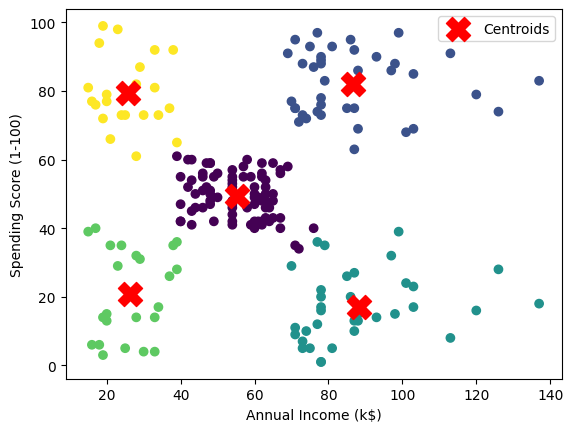

In [7]:
kmeans=KMeans(n_clusters=5,random_state=0,init='k-means++')
kmeans.fit(x)
y_means=kmeans.predict(x)
plt.scatter(x['Annual Income (k$)'],x['Spending Score (1-100)'],c=kmeans.labels_,cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c='red',s=300,label='Centroids',marker='X')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()